# 04 - Exploratory Data Analysis

This notebook summarizes turnout, vote concentration, split-ticket patterns, station-size differences, and source coverage gaps from the cleaned election tables.


## 1 · Load cleaned data

Load the cleaned station and vote tables generated by notebook 03.


In [9]:
# Core analysis libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.rcParams['font.family'] = 'Tahoma'
# Use a Thai-capable font for labels.

# Load cleaned datasets from notebook 03.
path = '../data/clean_data/'

station_df = pd.read_csv(f'{path}5_18_station.csv', encoding='utf-8-sig')
votes_df = pd.read_csv(f'{path}5_18_votes.csv', encoding='utf-8-sig')
party_station_df = pd.read_csv(f'{path}5_18_party_station.csv', encoding='utf-8-sig')
party_votes_df = pd.read_csv(f'{path}5_18_party_vote.csv', encoding='utf-8-sig')

print("Data loaded successfully.")
print(f"Constituency Stations: {len(station_df)}")
print(f"Constituency Votes: {len(votes_df)}")

Data loaded successfully.
Constituency Stations: 306
Constituency Votes: 2002


## 2 · Constituency overview

Calculate turnout and ballot-quality indicators for the available form 5/18 station records.


In [10]:
# Calculate turnout for the constituency records available in the cleaned dataset.
total_eligible = station_df['eligible_voters'].sum()
total_present = station_df['voters_present'].sum()
turnout_rate = (total_present / total_eligible) * 100

print(f"--- Constituency Overview ---")
print(f"Total Eligible Voters: {total_eligible:,.0f}")
print(f"Total Voters Present: {total_present:,.0f}")
print(f"Overall Turnout Rate: {turnout_rate:.2f}%\n")

# Spoiled-ballot and no-vote ratios.
total_used = station_df['ballots_used'].sum()
spoiled_rate = (station_df['ballots_spoiled'].sum() / total_used) * 100
no_vote_rate = (station_df['ballots_no_vote'].sum() / total_used) * 100

print(f"Spoiled Ballot Rate: {spoiled_rate:.2f}%")
print(f"No Vote Rate: {no_vote_rate:.2f}%")

--- Constituency Overview ---
Total Eligible Voters: 112,789
Total Voters Present: 77,700
Overall Turnout Rate: 68.89%

Spoiled Ballot Rate: 6.95%
No Vote Rate: 0.05%


## 3 · Turnout by subdistrict

Aggregate voter turnout by subdistrict to compare participation across local areas.


C:\Users\User\AppData\Local\Temp\ipykernel_10504\3937478731.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subdistrict_stats, x='turnout_pct', y='subdistrict', palette='viridis')


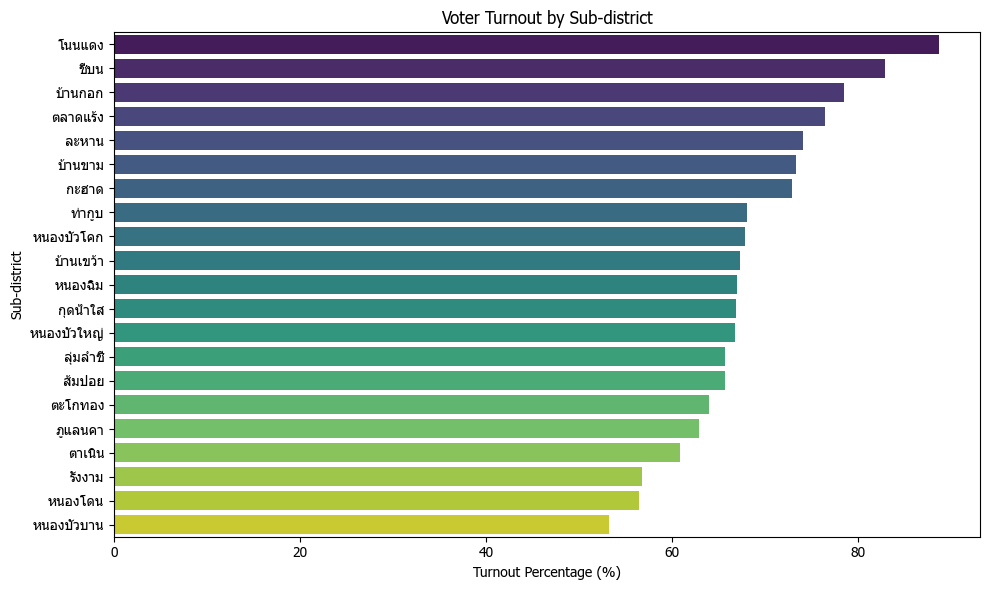

In [11]:
# Group by subdistrict to compare turnout.
subdistrict_stats = station_df.groupby('subdistrict').agg({
    'eligible_voters': 'sum',
    'voters_present': 'sum'
}).reset_index()

subdistrict_stats['turnout_pct'] = (subdistrict_stats['voters_present'] / subdistrict_stats['eligible_voters']) * 100
subdistrict_stats = subdistrict_stats.sort_values(by='turnout_pct', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=subdistrict_stats, x='turnout_pct', y='subdistrict', palette='viridis')
plt.title('Voter Turnout by Sub-district')
plt.xlabel('Turnout Percentage (%)')
plt.ylabel('Sub-district')
plt.tight_layout()
plt.show()

## 4 · Candidate vote totals

Summarize constituency candidate votes from the cleaned form 5/18 vote table.


C:\Users\User\AppData\Local\Temp\ipykernel_10504\3308234782.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=candidate_totals, x='votes', y='entity_name', palette='Blues_r')


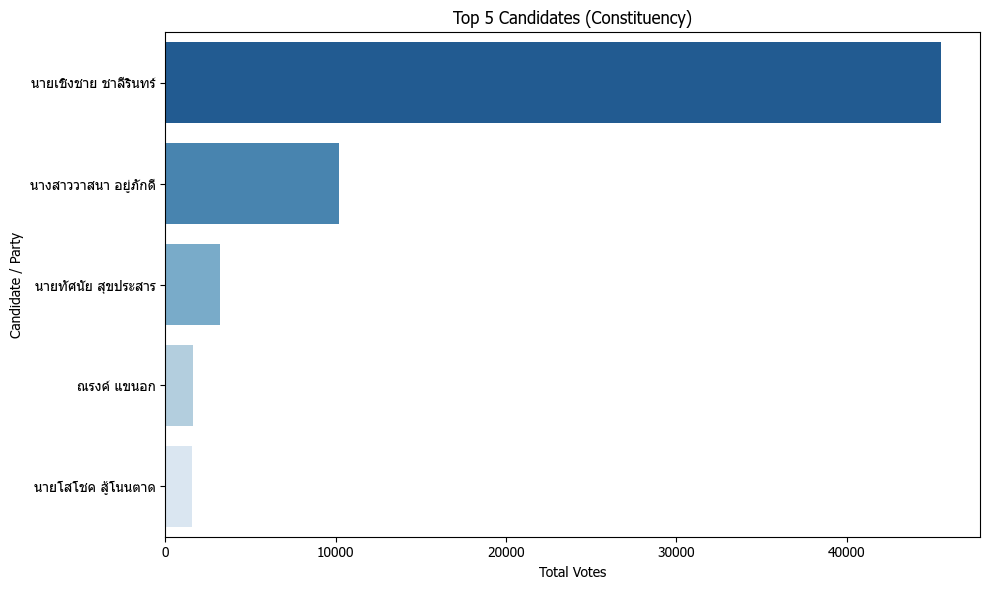

,entity_name,votes
5,นายเชิงชาย ชาลีรินทร์,45546.0
1,นางสาววาสนา อยู่ภักดี,10183.0
3,นายทัศนัย สุขประสาร,3221.0
0,ณรงค์ แขนอก,1628.0
6,นายโสโชค สู้โนนตาด,1569.0


In [12]:
# Aggregate constituency votes by candidate.
candidate_totals = votes_df.groupby('entity_name')['votes'].sum().reset_index()
candidate_totals = candidate_totals.sort_values(by='votes', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=candidate_totals, x='votes', y='entity_name', palette='Blues_r')
plt.title('Top 5 Candidates (Constituency)')
plt.xlabel('Total Votes')
plt.ylabel('Candidate / Party')
plt.tight_layout()
plt.show()

display(candidate_totals)

## 5 · Party-list vote totals

Summarize party-list votes from the cleaned form 5/18 (บช) vote table.


C:\Users\User\AppData\Local\Temp\ipykernel_10504\4207055532.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_totals, x='votes', y='entity_name', palette='Oranges_r')


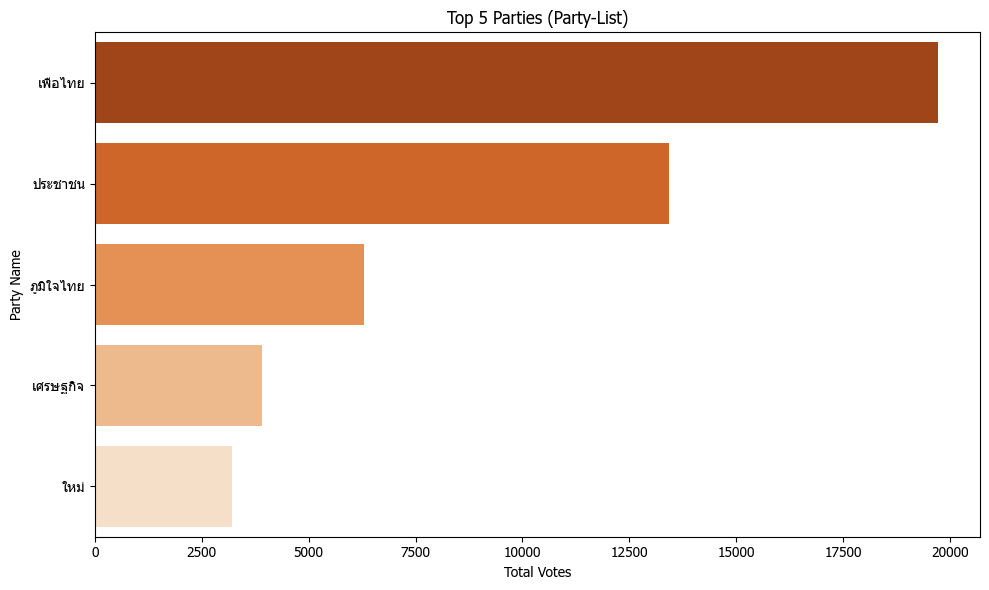

,entity_name,votes
39,เพื่อไทย,19715.0
9,ประชาชน,13425.0
24,ภูมิใจไทย,6291.0
40,เศรษฐกิจ,3906.0
45,ใหม่,3207.0


In [13]:
# Aggregate party-list votes by party.
party_totals = party_votes_df.groupby('entity_name')['votes'].sum().reset_index()
party_totals = party_totals.sort_values(by='votes', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=party_totals, x='votes', y='entity_name', palette='Oranges_r')
plt.title('Top 5 Parties (Party-List)')
plt.xlabel('Total Votes')
plt.ylabel('Party Name')
plt.tight_layout()
plt.show()

display(party_totals)

## 6 · Winning margin

Compare the top two constituency candidates and calculate the vote margin.


In [14]:
# Calculate the margin between the top two candidates.
top_2 = candidate_totals.head(2).reset_index(drop=True)
if len(top_2) >= 2:
    winner_votes = top_2.loc[0, 'votes']
    runner_up_votes = top_2.loc[1, 'votes']
    margin = winner_votes - runner_up_votes
    margin_pct = (margin / total_present) * 100
    
    print(f"Winning Candidate: {top_2.loc[0, 'entity_name']} ({winner_votes:,} votes)")
    print(f"Runner-up: {top_2.loc[1, 'entity_name']} ({runner_up_votes:,} votes)")
    print(f"Margin of Victory: {margin:,} votes ({margin_pct:.2f}% of total voters)")
    
    if margin_pct < 5.0:
        print("Interpretation: the leading candidates are separated by a narrow margin.")
    else:
        print("Interpretation: the winning candidate has a clear lead.")

Winning Candidate: นายเชิงชาย ชาลีรินทร์ (45,546.0 votes)
Runner-up: นางสาววาสนา อยู่ภักดี (10,183.0 votes)
Margin of Victory: 35,363.0 votes (45.51% of total voters)
Interpretation: the winning candidate has a clear lead.


## 7 · Split-ticket comparison

Compare constituency candidate votes with party-list votes by party.


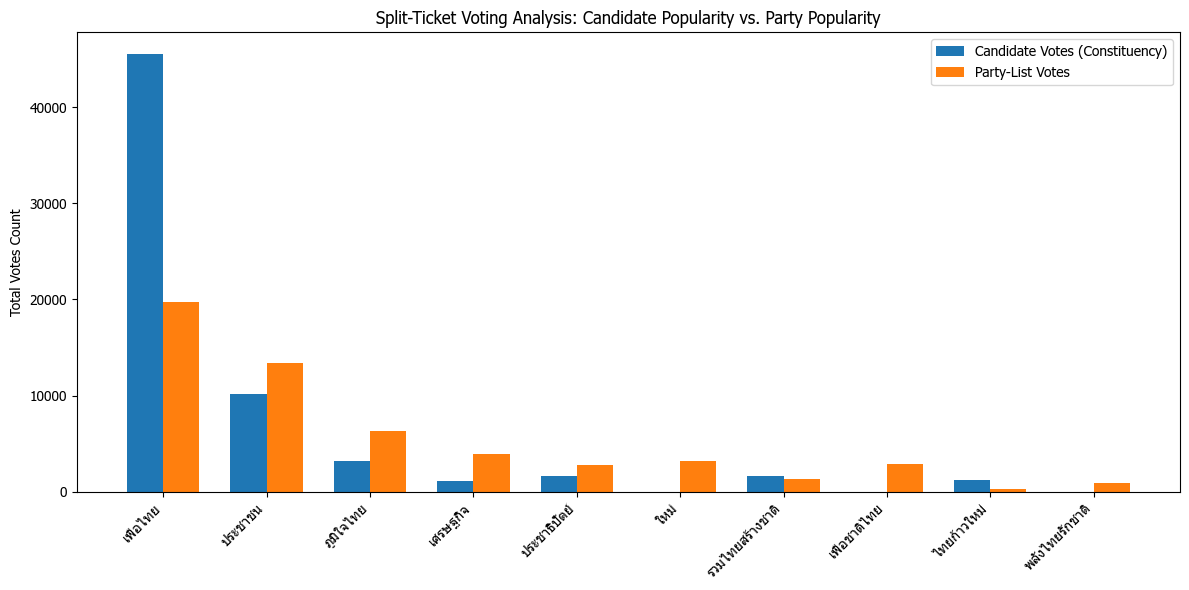

--- Split Voting Summary ---
Positive Vote_Gap (+): Voters chose the Candidate, but picked a different Party on the 2nd ballot.
Negative Vote_Gap (-): Voters chose the Party, but picked a different Candidate on the 1st ballot.



,Party,Candidate_Votes,Party_List_Votes,Vote_Gap
39,เพื่อไทย,45546.0,19715.0,25831.0
9,ประชาชน,10183.0,13425.0,-3242.0
24,ภูมิใจไทย,3221.0,6291.0,-3070.0
40,เศรษฐกิจ,1108.0,3906.0,-2798.0
11,ประชาธิปัตย์,1628.0,2714.0,-1086.0
45,ใหม่,0.0,3207.0,-3207.0
28,รวมไทยสร้างชาติ,1569.0,1334.0,235.0
36,เพื่อชาติไทย,0.0,2879.0,-2879.0
47,ไทยก้าวใหม่,1185.0,274.0,911.0
22,พลังไทยรักชาติ,0.0,866.0,-866.0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Aggregate constituency candidate votes by party.
candidate_by_party = votes_df.groupby('party_name')['votes'].sum().reset_index()
candidate_by_party.rename(columns={'party_name': 'Party', 'votes': 'Candidate_Votes'}, inplace=True)

# Aggregate party-list votes by party.
party_list = party_votes_df.groupby('entity_name')['votes'].sum().reset_index()
party_list.rename(columns={'entity_name': 'Party', 'votes': 'Party_List_Votes'}, inplace=True)

# Merge constituency and party-list totals by party.
comparison_df = pd.merge(candidate_by_party, party_list, on='Party', how='outer').fillna(0)

# Calculate the difference between constituency and party-list totals.
comparison_df['Vote_Gap'] = comparison_df['Candidate_Votes'] - comparison_df['Party_List_Votes']

# Keep the top parties by combined vote total for visualization.
comparison_df['Total_Combined'] = comparison_df['Candidate_Votes'] + comparison_df['Party_List_Votes']
top_10_parties = comparison_df.sort_values('Total_Combined', ascending=False).head(10)

# Plot a grouped bar chart.
x = np.arange(len(top_10_parties['Party']))
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, top_10_parties['Candidate_Votes'], width, label='Candidate Votes (Constituency)', color='#1f77b4')
rects2 = ax.bar(x + width/2, top_10_parties['Party_List_Votes'], width, label='Party-List Votes', color='#ff7f0e')

# Chart labels and title.
ax.set_ylabel('Total Votes Count')
ax.set_title('Split-Ticket Voting Analysis: Candidate Popularity vs. Party Popularity')
ax.set_xticks(x)
ax.set_xticklabels(top_10_parties['Party'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

# Display the exact vote gap table.
display_cols = ['Party', 'Candidate_Votes', 'Party_List_Votes', 'Vote_Gap']
print("--- Split Voting Summary ---")
print("Positive Vote_Gap (+): Voters chose the Candidate, but picked a different Party on the 2nd ballot.")
print("Negative Vote_Gap (-): Voters chose the Party, but picked a different Candidate on the 1st ballot.\n")
display(top_10_parties[display_cols])

## 8 · Station-size comparison

Use eligible-voter count as a proxy for polling-station size and compare party-list preferences across size groups.


In [16]:
# Polling-station size comparison.
print("\n--- Insight: Voting Preference by Station Size ---")

# Create size categories from eligible-voter tertiles.
station_df['station_size'] = pd.qcut(station_df['eligible_voters'], q=3, labels=['Small', 'Medium', 'Large'])

# Merge station-size categories with party-list votes.
party_with_size = pd.merge(
    party_votes_df, 
    station_df[['station_code', 'station_size']], 
    on='station_code', 
    how='inner'
)

# Aggregate party-list votes by station-size group.
size_preference = party_with_size.groupby(['station_size', 'entity_name'], observed=True)['votes'].sum().reset_index()
# Keep the top three parties for a compact comparison.
top_3_parties = party_totals.head(3)['entity_name'].tolist()
size_preference_filtered = size_preference[size_preference['entity_name'].isin(top_3_parties)]

# Pivot for display.
pivot_size = size_preference_filtered.pivot(index='station_size', columns='entity_name', values='votes')
display(pivot_size)


--- Voting Preference by Station Size ---


entity_name,ประชาชน,ภูมิใจไทย,เพื่อไทย
station_size,,,
Small,3465.0,1693.0,5118.0
Medium,4241.0,2141.0,6126.0
Large,6205.0,2682.0,9000.0


## 9 · Missing constituency station check

Compare cleaned form 5/18 station records against the reference station list.


In [23]:
# Load the cleaned station data to check.
current_df = pd.read_csv("../data/clean_data/5_18_station.csv")
current_df['station_code'] = current_df['station_code'].str.replace('?', '', regex=False)  # Remove uncertain-match marker before comparing station codes.

# Load the reference station list.
reference_df = pd.read_csv("../data/external/stations.csv")

# Find station codes present in the reference list but absent from the cleaned data.
missing_mask = ~reference_df['station_code'].isin(current_df['station_code'])
missing_stations_df = reference_df[missing_mask]

# Print the summary.
print("=== MISSING STATION CHECK ===")
print(f"Total stations in Reference: {len(reference_df)}")
print(f"Total stations in Current:   {len(current_df)}")
print(f"Number of MISSING stations:  {len(missing_stations_df)}\n")

# Save the missing-station list for dashboard review.
if len(missing_stations_df) > 0:
    save_path = "../data/clean_data/5_18_missing_stations_report.csv"
    missing_stations_df.to_csv(save_path, index=False)
    print(f"Saved the missing-station list to: {save_path}")
    print("\nHere are the first few missing stations:")
    print(missing_stations_df[['station_code']].head())
else:
    print("No missing stations found.")

=== MISSING STATION CHECK ===
Total stations in Reference: 341
Total stations in Current:   306
Number of MISSING stations:  46

Saved the missing-station list to: ../data/clean_data/5_18_missing_stations_report.csv

Here are the first few missing stations:
         station_code
9    36-02-360201-010
15  36-02-360201T-001
16  36-02-360201T-002
17  36-02-360201T-003
18  36-02-360201T-004


## 10 · Missing party-list station check

Compare cleaned form 5/18 (บช) station records against the reference station list.


In [24]:
# Load the cleaned station data to check.
current_df = pd.read_csv("../data/clean_data/5_18_party_station.csv")
current_df['station_code'] = current_df['station_code'].str.replace('?', '', regex=False)  # Remove uncertain-match marker before comparing station codes.

# Load the reference station list.
reference_df = pd.read_csv("../data/external/stations.csv")

# Find station codes present in the reference list but absent from the cleaned data.
missing_mask = ~reference_df['station_code'].isin(current_df['station_code'])
missing_stations_df = reference_df[missing_mask]

# Print the summary.
print("=== MISSING STATION CHECK ===")
print(f"Total stations in Reference: {len(reference_df)}")
print(f"Total stations in Current:   {len(current_df)}")
print(f"Number of MISSING stations:  {len(missing_stations_df)}\n")

# Save the missing-station list for dashboard review.
if len(missing_stations_df) > 0:
    save_path = "../data/clean_data/5_18_party_missing_stations_report.csv"
    missing_stations_df.to_csv(save_path, index=False)
    print(f"Saved the missing-station list to: {save_path}")
    print("\nHere are the first few missing stations:")
    print(missing_stations_df[['station_code']].head())
else:
    print("No missing stations found.")

=== MISSING STATION CHECK ===
Total stations in Reference: 341
Total stations in Current:   305
Number of MISSING stations:  69

Saved the missing-station list to: ../data/clean_data/5_18_party_missing_stations_report.csv

Here are the first few missing stations:
         station_code
15  36-02-360201T-001
16  36-02-360201T-002
17  36-02-360201T-003
18  36-02-360201T-004
19  36-02-360201T-005
